# Conditional Graph 🚧
## Exercise - 4
---
### Objectives:
- Implement conditional logic to route the flow of data to different nodes.
- Use START and END nodes to manage entry and exit points explicitly.
- Design multiple nodes to perform different operations (e.g., addition, subtraction).
- Create a router node to handle decision-making and control graph flow.

### Main Goal:
How to use `add_conditional_edges()`

/home/rakib/miniconda3/envs/langgraph/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


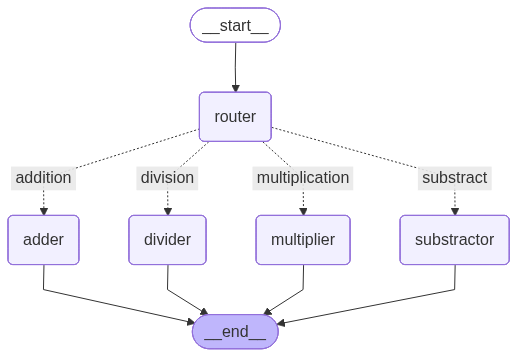

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
{
    "final result": {
        "nm1": 100,
        "opt": "*",
        "nm2": 2,
        "res": "Your ADDITION result is 200"
    }
}
####################################################################################################


In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from tools.VGraph import Helper

__tools__ = Helper()

class Agent4(TypedDict):
    nm1: int
    opt: Literal["+", "-", "*", "/"]
    nm2: int
    res: str

def adder(state: Agent4) -> Agent4:
    """Adds number1 and number2"""
    res = state["nm1"] + state["nm2"]
    state["res"] = f"Your ADDITION result is {res}"
    return state

def subs(state: Agent4) -> Agent4:
    """"Substract number1 and number2"""
    res = state["nm1"] - state["nm2"]
    state["res"] = f"Your SUBSTRACTION result is {res}"
    return state

def multi(state: Agent4) -> Agent4:
    """multiply number1 and number2"""
    res = state["nm1"] * state["nm2"]
    state["res"] = f"Your ADDITION result is {res}"
    return state

def div(state: Agent4) -> Agent4:
    """"divides number1 and number2"""
    res = state["nm1"] / state["nm2"]
    state["res"] = f"Your SUBSTRACTION result is {res}"
    return state

def router(state: Agent4) -> Agent4:
    """Select the next node"""
    if state["opt"]=="+":
        return "addition"
    elif state["opt"]=="-":
        return "substract"
    elif state["opt"]=="*":
        return "multiplication"
    elif state["opt"]=="/":
        return "division"

graph = StateGraph(Agent4)

graph.add_node("adder", adder)
graph.add_node("substractor", subs)
graph.add_node("multiplier", multi)
graph.add_node("divider", div)
graph.add_node("router", lambda x:x)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    source="router",
    path=router,
    path_map={
        "addition": "adder",
        "substract": "substractor",
        "multiplication": "multiplier",
        "division": "divider"
    }
)
graph.add_edge("adder", END)
graph.add_edge("substractor", END)

app = graph.compile()
__tools__.view_graph(app=app)

res = app.invoke(
    {
        "nm1": 100,
        "opt":"*",
        "nm2": 2
    }
)

__tools__.monitor({"final result": res})